**Option 1: Upload the file**

Run the following cell to upload the `robot_haptic_dataset.csv` file.

[INFO] Loaded dataset: (500, 12) rows/columns
   case_id  surgeon_experience_years    procedure_type  tool_velocity_mm_s  \
0        1                         7  robotic_assisted           13.767353   
1        2                        20       laparoscopy           75.487409   
2        3                        15         endoscopy           52.078104   
3        4                        11         endoscopy           30.117921   
4        5                         8       laparoscopy           15.445405   

   applied_force_N  force_feedback_N  position_error_mm  tissue_resistance_N  \
0         7.985719          5.399570           0.469286             2.390178   
1         4.867071          2.230499           4.548134             4.077369   
2         1.261351          0.219996           3.346001             1.633439   
3         1.339339          2.487894           4.146434             2.136634   
4         6.887096          9.761150           4.394895             5.513166   

   h

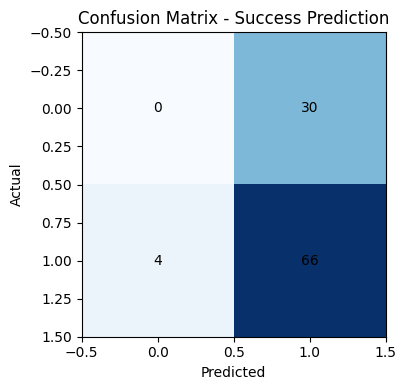

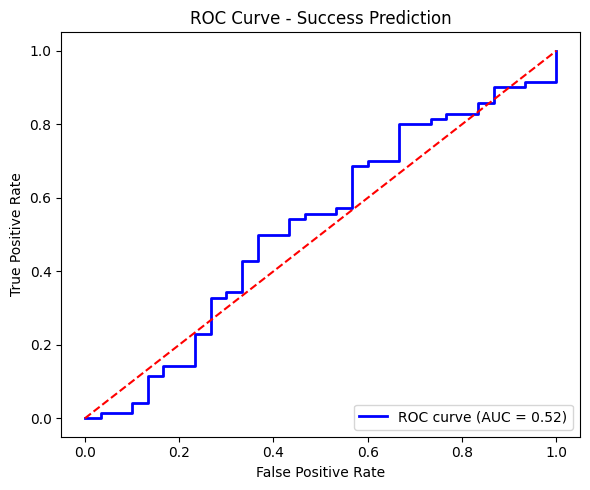

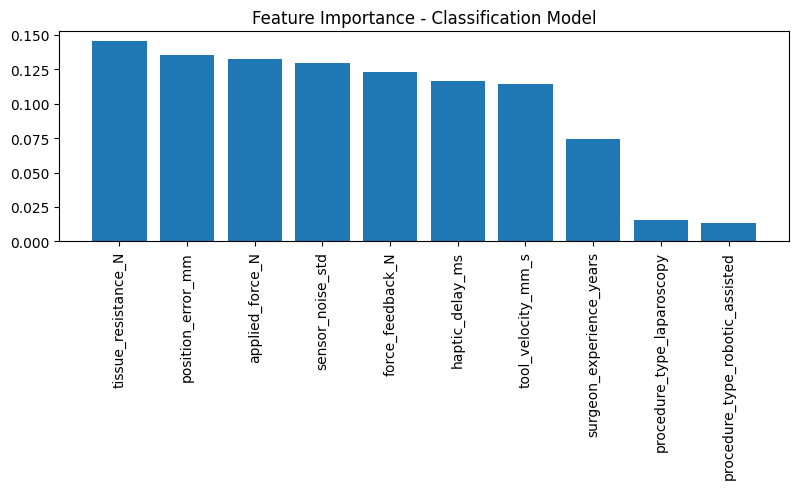

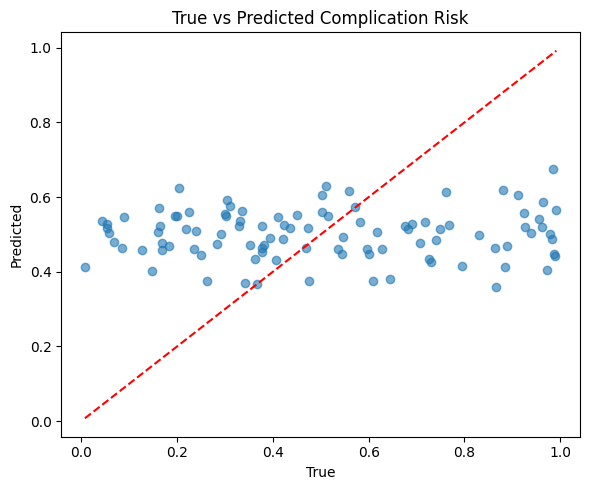

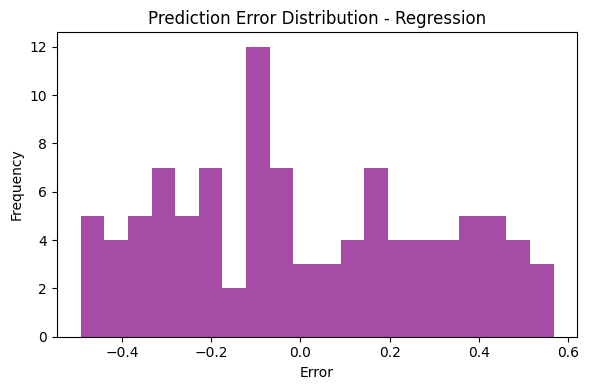

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, r2_score, roc_curve, auc
)
import joblib

# Load dataset
csv_path = "robot_haptic_dataset.csv"
df = pd.read_csv(csv_path)
print(f"[INFO] Loaded dataset: {df.shape} rows/columns")
print(df.head())

# Feature/target selection
target_classification = 'success'
target_regression = 'complication_risk'
drop_columns = ['case_id']

X = df.drop(columns=drop_columns + [target_classification, target_regression])
y_clf = df[target_classification]
y_reg = df[target_regression]

#  Preprocessing
# Identify categorical columns to encode
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)  # Encode categorical vars

# Standardize numerical features
numerical_cols = X_encoded.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_scaled = X_encoded.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])


# Train Classifier
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
clf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)
y_proba_c = clf.predict_proba(X_test_c)[:, 1]  # For ROC curve

print("\n[Classifier Results]")
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print(classification_report(y_test_c, y_pred_c))
cm = confusion_matrix(y_test_c, y_pred_c)
print("Confusion Matrix:\n", cm)

# Train Regressor
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)
reg = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

print("\n[Regressor Results]")
print(f"MSE: {mean_squared_error(y_test_r, y_pred_r):.6f}")
print(f"R²: {r2_score(y_test_r, y_pred_r):.4f}")

# Save Models
os.makedirs("output", exist_ok=True)
joblib.dump(clf, "output/robot_haptic_success_rf.pkl")
joblib.dump(reg, "output/robot_haptic_complication_rf.pkl")
joblib.dump(scaler, "output/robot_haptic_scaler.pkl")
joblib.dump(X_scaled.columns.tolist(), "output/robot_haptic_columns.pkl")


#  Confusion Matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix - Success Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha='center', va='center')
plt.tight_layout()
plt.show()

#  ROC Curve
fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Success Prediction')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Feature Importance
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(8,5))
plt.bar(range(X_scaled.shape[1]), importances[indices], align='center')
plt.xticks(range(X_scaled.shape[1]), X_scaled.columns[indices], rotation=90)
plt.title("Feature Importance - Classification Model")
plt.tight_layout()
plt.show()

# Regression: Predicted vs Actual
plt.figure(figsize=(6,5))
plt.scatter(y_test_r, y_pred_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()],[y_test_r.min(), y_test_r.max()], 'r--') # Adjusted line to fit data range
plt.title('True vs Predicted Complication Risk')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

# Regression: Error Histogram
errors = y_test_r - y_pred_r
plt.figure(figsize=(6,4))
plt.hist(errors, bins=20, color='purple', alpha=0.7)
plt.title("Prediction Error Distribution - Regression")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [2]:

import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 500

df = pd.DataFrame({
    "case_id": range(1, n_samples + 1),
    "surgeon_experience_years": np.random.randint(1, 21, n_samples),
    "procedure_type": np.random.choice(["laparoscopy", "endoscopy", "robotic_assisted"], n_samples),
    "tool_velocity_mm_s": np.random.uniform(5, 80, n_samples),
    "applied_force_N": np.random.uniform(0.1, 10, n_samples),
    "force_feedback_N": np.random.uniform(0.1, 10, n_samples),
    "position_error_mm": np.random.uniform(0, 5, n_samples),
    "tissue_resistance_N": np.random.uniform(0.1, 6, n_samples),
    "haptic_delay_ms": np.random.uniform(1, 200, n_samples),
    "sensor_noise_std": np.random.uniform(0.001, 0.2, n_samples),
    "success": np.random.choice([0, 1], n_samples, p=[0.3, 0.7]),
    "complication_risk": np.random.uniform(0, 1, n_samples)
})

df.to_csv("robot_haptic_dataset.csv", index=False)
print("Dataset saved to robot_haptic_dataset.csv")


Dataset saved to robot_haptic_dataset.csv


**Option 2: Update the `DATA_PATH`**

If the file is located elsewhere (e.g., in Google Drive), update the `DATA_PATH` variable in the original code cell to the correct path.